In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.fft import fft
import matplotlib.pyplot as plt
import seaborn as sns

Loaded signal with 485063 data points.


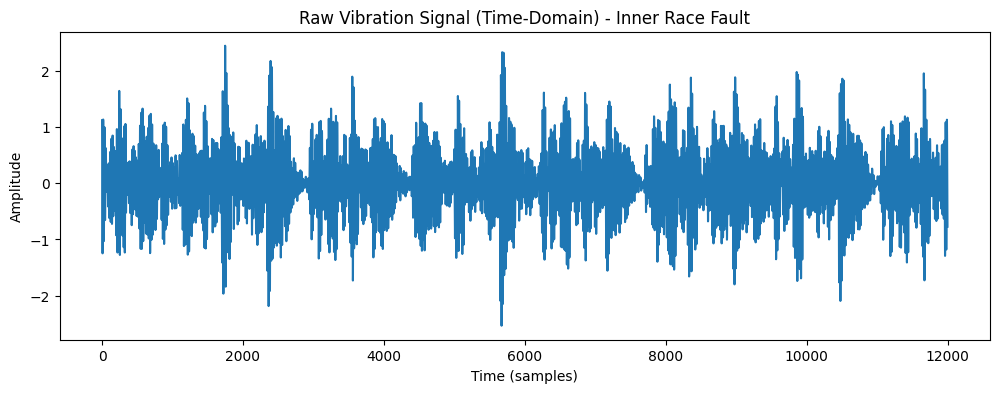

In [2]:
# Loading the file.
mat_file=loadmat(r'D:\Engineering\Mech AI Projects\bearing_fault_diagnosis\data\IR021_1_214.mat')
mat_file
mat_file.keys()
key_name=[key for key in mat_file.keys() if key.endswith('_DE_time')][0]
vibrational_signal=mat_file[key_name].flatten()

print(f"Loaded signal with {len(vibrational_signal)} data points.")

# Plot the raw vibration signal (time-domain)
plt.figure(figsize=(12, 4))
sns.lineplot(vibrational_signal[:12000]) # Plot first 5000 points
plt.title("Raw Vibration Signal (Time-Domain) - Inner Race Fault")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()

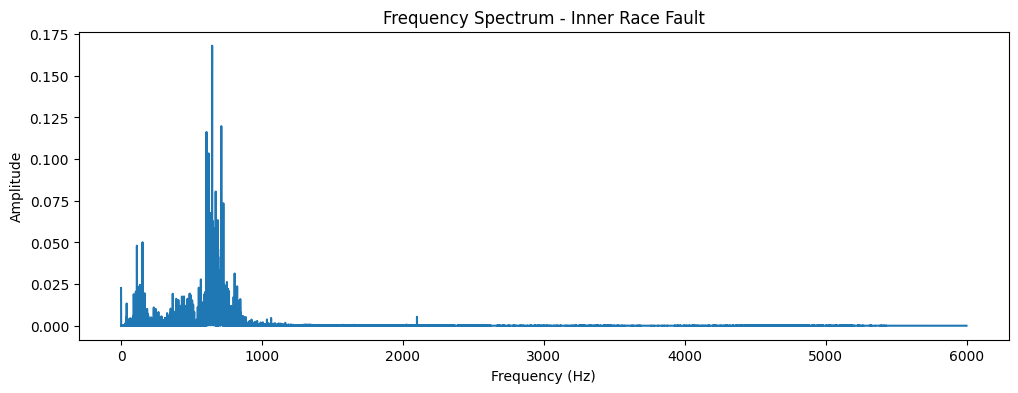

In [3]:
# Apply FFT to move to Frequency Domain
N = len(vibrational_signal)
sampling_rate = 12000 # 12k Drive End data was sampled at 12kHz
# Compute the Fast Fourier Transform
yf = fft(vibrational_signal)
# Compute the frequency axis
xf = np.linspace(0.0, 1.0/(2.0/sampling_rate), N//2)

# Plot the frequency spectrum
plt.figure(figsize=(12, 4))
# We plot the absolute value and normalize, only showing the positive frequencies
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title("Frequency Spectrum - Inner Race Fault")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

In [4]:
import os
from scipy.stats import kurtosis, skew

# Function to extract features
def extract_features(signal):
    """Extracts statistical features from a signal's frequency spectrum."""
    N = len(signal)
    yf = fft(signal)
    # Get the magnitude of the spectrum
    spectrum = 2.0/N * np.abs(yf[0:N//2])
    
    # Statistical features
    max=np.max(spectrum)
    min=np.min(spectrum)
    std=np.std(spectrum)
    rms = np.sqrt(np.mean(spectrum**2))
    kurt = kurtosis(spectrum)
    skewness = skew(spectrum)
    crest_factor = np.max(np.abs(spectrum)) / rms
    form_factor = rms / np.mean(np.abs(spectrum))
    
    return [max, min, std, rms, kurt, skewness, crest_factor,form_factor]

# Process all files and build a dataset
data_dir = r'D:\Engineering\Mech AI Projects\bearing_fault_diagnosis\data' # Directory with .mat files
features_list = []
labels_list = []

# List of fault types we want to classify
fault_types = ['Normal', 'IR007','IR014','IR021', 'B007','B014','B021', 'OR007','OR014','OR021'] 

for filename in os.listdir(data_dir):
    for fault in fault_types:
        if fault in filename:
            # Load the data
            mat_file = loadmat(os.path.join(data_dir, filename))
            key_name = [k for k in mat_file.keys() if k.endswith('_DE_time')][0]
            signal = mat_file[key_name].flatten()
            for i in range(0,len(signal)//1200):
                # Extract a segment of the signal
                segment = signal[i*1200:(i+1)*1200]
                # Extract features and append
                features = extract_features(segment)
                features_list.append(features)
                labels_list.append(fault)

# Create a Pandas DataFrame
df = pd.DataFrame(features_list, columns=['Max','Min','Std','RMS', 'Kurtosis', 'Skewness', 'Crest Factor', 'Form Factor'])
df['label'] = labels_list

print("Feature DataFrame created:")
print(df)
# Remove duplicates
df=df.drop_duplicates()

# Define features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label'].apply(lambda x: 'Normal' if x == 'Normal' else 'Fault')
y_new=pd.DataFrame(y.map({'Normal': 0, 'Fault': 1}),columns=['label'])


Feature DataFrame created:
           Max       Min       Std       RMS   Kurtosis  Skewness  \
0     0.056500  0.000004  0.006449  0.006791  28.089721  4.925901   
1     0.082412  0.000001  0.007551  0.007896  40.962657  5.778020   
2     0.055951  0.000018  0.006878  0.007288  23.582036  4.603397   
3     0.085471  0.000020  0.009241  0.009633  38.566858  5.858946   
4     0.070306  0.000006  0.007591  0.007967  28.571617  4.966941   
...        ...       ...       ...       ...        ...       ...   
4045  0.039897  0.000007  0.003614  0.003903  46.757351  5.986963   
4046  0.041132  0.000013  0.003847  0.004169  38.542892  5.478618   
4047  0.045940  0.000005  0.004300  0.004674  31.362890  4.866614   
4048  0.040370  0.000029  0.003787  0.004129  37.582309  5.343423   
4049  0.043690  0.000015  0.003623  0.003976  46.406800  5.765650   

      Crest Factor  Form Factor   label  
0         8.319668     3.191112    B007  
1        10.436680     3.417210    B007  
2         7.677441

<Axes: >

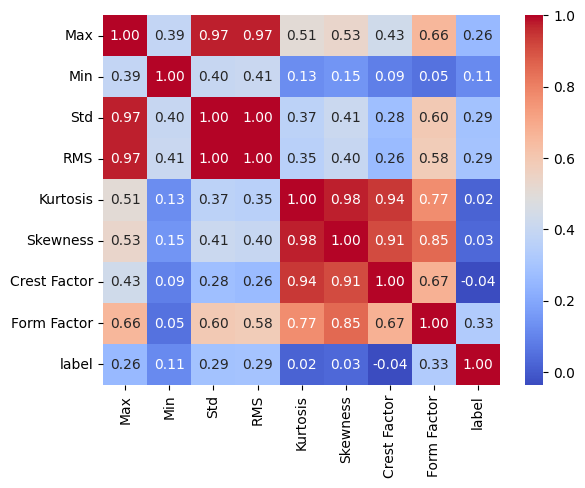

In [5]:
# Correlation matrix Visualization
df_new=pd.concat([X,y_new],axis=1)
corr_matrix=df_new.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Model Accuracy: 99.92%


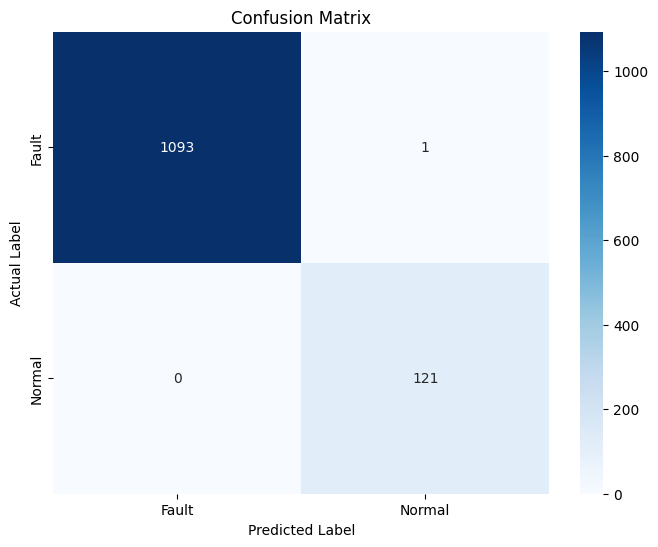

In [6]:
# Train a Machine Learning Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from sklearn.model_selection import GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Initialize and train the classifier
rf_model = RandomForestClassifier(random_state=42,class_weight='balanced')

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,             # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,        # Use all CPU cores
    verbose=2         # Show progress
)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Make predictions
y_pred = best_rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=best_rf.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [7]:
# saving the model and scaler
import joblib
joblib.dump(best_rf, r'D:\Engineering\Mech AI Projects\bearing_fault_diagnosis\outputs/bearing_fault_model.pkl')
joblib.dump(scaler, r'D:\Engineering\Mech AI Projects\bearing_fault_diagnosis\outputs/scaler.pkl')
print('Model and scaler saved successfully.')

Model and scaler saved successfully.


In [8]:
# checking the saved model predictions.
model = joblib.load(r'D:\Engineering\Mech AI Projects\bearing_fault_diagnosis\outputs\bearing_fault_model.pkl')
print(model.predict(X_test[:5]))
print(y_test[:5])

['Fault' 'Fault' 'Fault' 'Fault' 'Fault']
1504    Fault
3602    Fault
2735    Fault
3489    Fault
1214    Fault
Name: label, dtype: object
